# 방범용 CCTV 위치와 인구 데이터분석
- https://data.busan.go.kr/
- 부산광역시_방범용 CCTV 정보 -> csv 파일 다운로드
  
- https://jumin.mois.go.kr/
- CCTV와 같은 날짜의 인구를 검색 -> csv 파일 다운로드

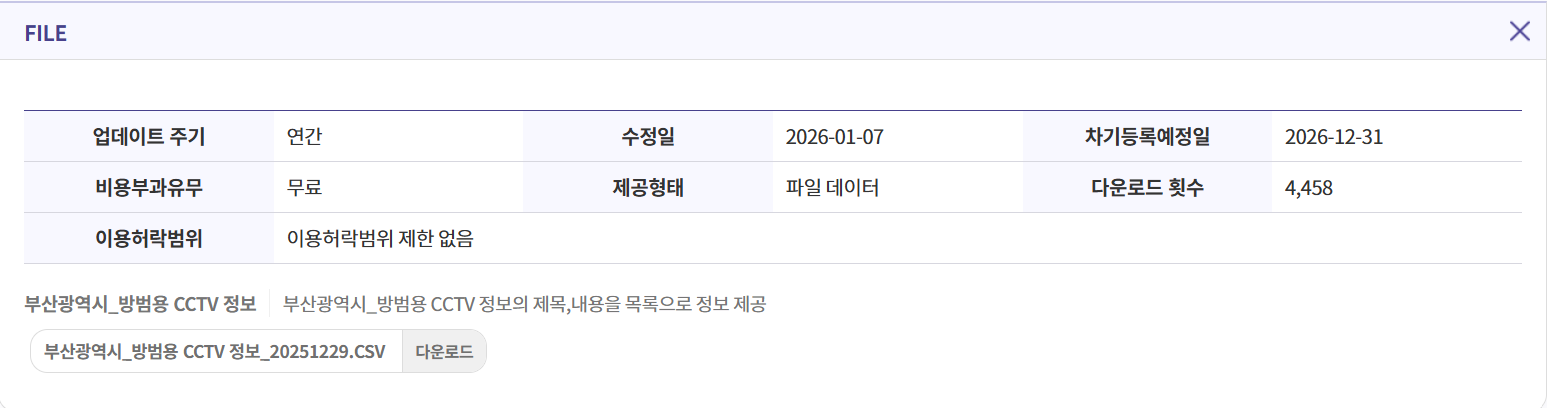

<hr />

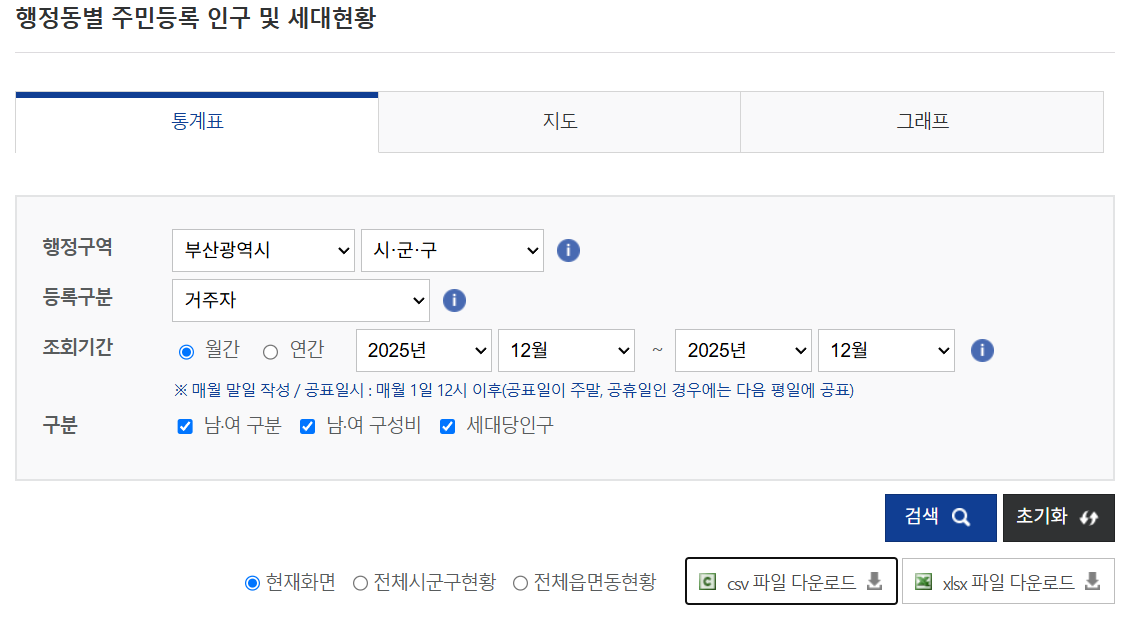

In [1]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Text(0.2, 0.4, '한글')

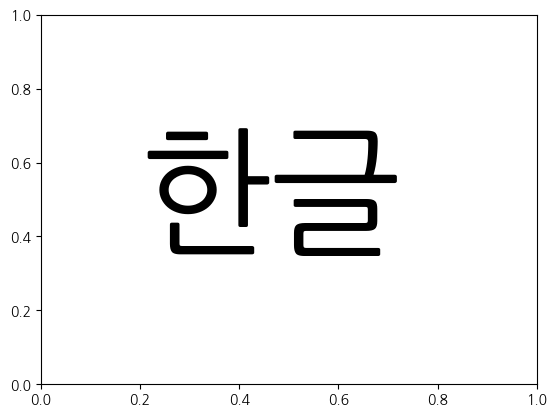

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [3]:
client_hdfs = InsecureClient('http://namenode:9870',user='hadoop')
path_cctv = "/dataset/부산광역시방범용CCTV정보202512.csv"
path_jumin = "/dataset/주민등록인구및세대현황202512.csv"

with client_hdfs.read(path_cctv, encoding='cp949') as reader:
    cctv = pd.read_csv(reader)
with client_hdfs.read(path_jumin, encoding='cp949') as reader:
    jumin = pd.read_csv(reader,thousands=",")  # thousands="," 콤마제거

# cctv
# jumin

In [4]:
cctv.rename(columns={'구군':'local'}, inplace=True)
cctv_count = cctv['local'].value_counts()
cctv_count
cctv['local'].describe()

count     21060
unique       16
top          남구
freq       2032
Name: local, dtype: object

In [5]:
jumin_data = jumin.loc[1:,'행정구역':'2025년12월_거주자 인구수']
jumin_data.columns = ['local','value']
jumin_data['local'] = jumin_data['local'].str.replace('부산광역시 ','')
jumin_data['local'] = [data[0] for data in jumin_data['local'].str.split(' ')] # jumin_data['local'].str.split('(').str[0].str.strip()
jumin_data

,local,value
1,중구,36223
2,서구,101406
3,동구,83352
4,영도구,101104
5,부산진구,363555
6,동래구,272339
7,남구,249640
8,북구,262076
9,해운대구,370561
10,사하구,285207


In [6]:
result = pd.merge(cctv_count, jumin_data, on='local')
result = result.set_index('local')
result

,count,value
local,,
남구,2032,249640
사하구,1823,285207
북구,1714,262076
해운대구,1683,370561
강서구,1668,150008
기장군,1508,174429
부산진구,1477,363555
금정구,1284,205802
연제구,1241,211062


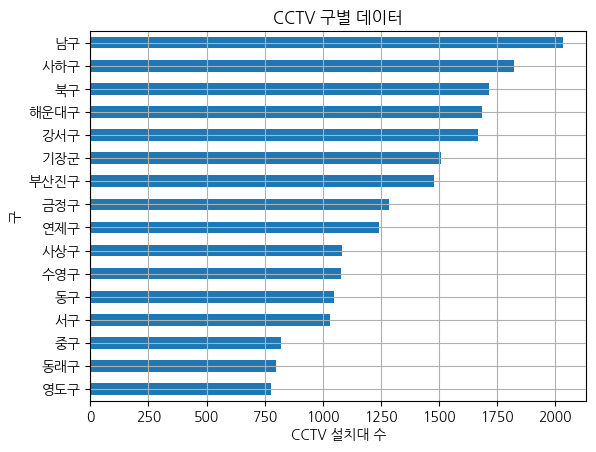

In [7]:
import matplotlib.pyplot as plt
result['count'].sort_values().plot(kind='barh', ylabel='구')
plt.title('CCTV 구별 데이터')
plt.xlabel('CCTV 설치대 수')
plt.grid()
plt.show()

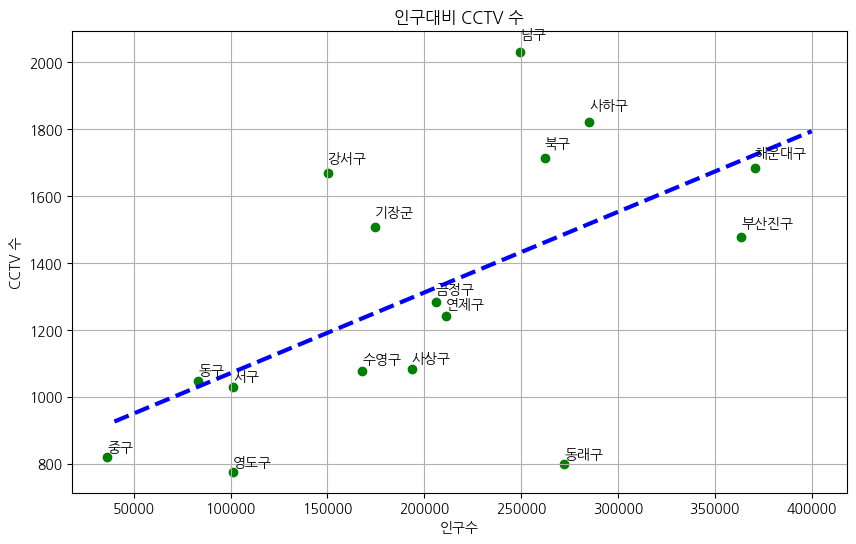

In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression

xx = result['value']
yy = result['count']

plt.figure(figsize=(10, 6))

plt.scatter(xx, yy, color='green')

# 회귀선 1
pf = np.polyfit(xx, yy, 1)
pf1d = np.poly1d(pf)
fx = np.linspace(40000, 400000, 10)
plt.plot(fx, pf1d(fx), ls='dashed',lw=3, color='b')

plt.title('인구대비 CCTV 수')
plt.xlabel('인구수')
plt.ylabel('CCTV 수')

# 점마다 각 구의 이름을 부여
gu = list(result.index)
for gg in gu:
    plt.text(result['value'].loc[gg], result['count'].loc[gg] * 1.02, gg)
    
# for i in range(len(result)):
#     plt.text(xx.iloc[i]*0.95, yy.iloc[i]*1.02, result['local'].iloc[i], fontsize=10)
    
plt.grid()
plt.show()

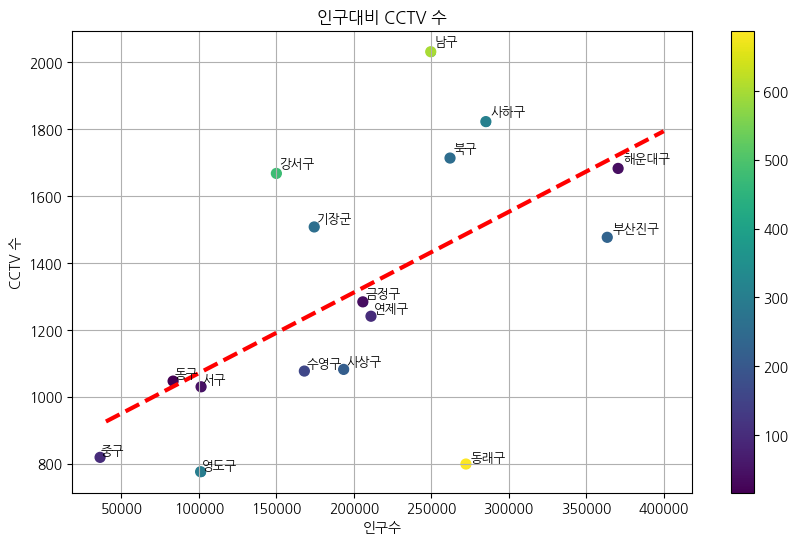

In [29]:
from sklearn.linear_model import LinearRegression
xx = result['value']
yy = result['count']

plt.figure(figsize=(10, 6))

plt.scatter(xx, yy, s=30)

# 회귀선 2
rx = xx.values.reshape(-1,1)
ry = yy.values
model = LinearRegression()
model.fit(rx, ry)

# 색을 부여 (편차)
result['dev'] = np.abs(result['count'] - model.predict(rx))

scatter = plt.scatter(xx, yy, c=result['dev'], s=50)

fx = np.linspace(40000, 400000, 10).reshape(-1, 1)
plt.plot(fx, model.predict(fx), c='r', lw=3, ls='--')

# 점마다 각 구의 이름을 부여
gu = list(result.index)
for gg in gu:
    plt.text(result['value'].loc[gg] * 1.01, result['count'].loc[gg] * 1.01, gg, fontsize=9)
    
# for i in range(len(result)):
#     plt.text(xx.iloc[i]*0.95, yy.iloc[i]*1.02, result['local'].iloc[i], fontsize=10)
plt.title('인구대비 CCTV 수')
plt.xlabel('인구수')
plt.ylabel('CCTV 수')
plt.grid()
plt.colorbar(scatter)
plt.show()